# AxonScope — batch-only CPU vs GPU benchmark

This notebook contains the **full benchmark code directly in its cells**.

It benchmarks batch execution for:

- `N = 5`
- `N = 50`
- `N = 500`
- `N = 1000`

For every fiber, it records only the center-compartment membrane voltage:

```python
axs.Recording.center("Vm")
```

The notebook runs CPU and GPU in separate Python processes, then compares:

1. synchronized batch runtime;
2. GPU speed-up;
3. CPU–GPU numerical differences in the recorded `Vcenter` traces.

Before running it in Colab, select:

**Runtime → Change runtime type → Hardware accelerator → GPU**

## 1. Benchmark configuration

In [1]:
# @title Configuration

FIBER_COUNTS = [5, 50, 500]#, 1000]
REPEATS = 1

DURATION_MS = 20.0
DT_MS = 0.01

AXON_LENGTH_UM = 100.0
AXON_DIAMETER_UM = 0.5
COMPARTMENTS = 51

Y_MIN_UM = 10.0
Y_MAX_UM = 250.0

REPO_URL = "https://github.com/louisreg/AxonScope.git"
REPO_DIR = "/content/AxonScope"
RESULTS_DIR = "/content/axonscope_batch_cpu_gpu_results"

UPDATE_REPO = False
FORCE_REINSTALL = False

print({
    "fiber_counts": FIBER_COUNTS,
    "repeats": REPEATS,
    "duration_ms": DURATION_MS,
    "dt_ms": DT_MS,
    "recording": "Vcenter only",
})

{'fiber_counts': [5, 50, 500], 'repeats': 1, 'duration_ms': 20.0, 'dt_ms': 0.01, 'recording': 'Vcenter only'}


## 2. Install JAX and AxonScope

This cell is idempotent within the same Colab VM:

- it installs `jax[cuda12]` only when GPU support is missing;
- it clones AxonScope only when the repository is absent;
- it installs AxonScope only when needed.

In [2]:
import json
import shutil
import subprocess
import sys
from pathlib import Path

repo_dir = Path(REPO_DIR)
marker_path = repo_dir / ".axonscope_batch_benchmark_ready"


def run(command):
    print("$", " ".join(map(str, command)))
    subprocess.run(list(map(str, command)), check=True)


def probe_environment():
    probe_source = r"""
import json

result = {
    "jax_version": None,
    "cpu": False,
    "gpu": False,
    "axonscope": False,
}

try:
    import jax
    result["jax_version"] = jax.__version__

    try:
        result["cpu"] = bool(jax.devices("cpu"))
    except Exception:
        pass

    try:
        result["gpu"] = bool(jax.devices("gpu"))
    except Exception:
        pass
except Exception:
    pass

try:
    import axonscope
    result["axonscope"] = True
except Exception:
    pass

print("__PROBE__" + json.dumps(result))
"""

    process = subprocess.run(
        [sys.executable, "-c", probe_source],
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
    )

    for line in reversed(process.stdout.splitlines()):
        if line.startswith("__PROBE__"):
            return json.loads(line.removeprefix("__PROBE__"))

    return {
        "jax_version": None,
        "cpu": False,
        "gpu": False,
        "axonscope": False,
    }


if shutil.which("nvidia-smi") is None:
    raise RuntimeError(
        "No NVIDIA GPU is visible. "
        "Select a GPU runtime in Google Colab."
    )

before = probe_environment()

if FORCE_REINSTALL or not before["gpu"]:
    command = [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        "--upgrade",
    ]
    if FORCE_REINSTALL:
        command.append("--force-reinstall")
    command.append("jax[cuda12]")
    run(command)
else:
    print(
        f"✓ JAX {before['jax_version']} already has CPU and GPU support."
    )

fresh_clone = False

if not (repo_dir / ".git").exists():
    if repo_dir.exists():
        shutil.rmtree(repo_dir)

    run([
        "git",
        "clone",
        "--depth",
        "1",
        "--branch",
        "main",
        REPO_URL,
        repo_dir,
    ])
    fresh_clone = True

elif UPDATE_REPO:
    run(["git", "-C", repo_dir, "fetch", "--depth", "1", "origin", "main"])
    run(["git", "-C", repo_dir, "reset", "--hard", "origin/main"])

else:
    print("✓ AxonScope repository is already present.")

if (
    FORCE_REINSTALL
    or fresh_clone
    or UPDATE_REPO
    or not marker_path.exists()
    or not before["axonscope"]
):
    command = [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        "--upgrade",
    ]
    if FORCE_REINSTALL:
        command.append("--force-reinstall")

    command.extend(["-e", f"{repo_dir}[benchmark]"])
    run(command)
    marker_path.write_text("ready")

else:
    print("✓ AxonScope is already installed in this Colab VM.")

after = probe_environment()
print("\nEnvironment:", after)

if not (
    after["axonscope"]
    and after["cpu"]
    and after["gpu"]
):
    raise RuntimeError(
        "AxonScope or the JAX CPU/GPU backends are not ready."
    )

✓ JAX 0.7.2 already has CPU and GPU support.
✓ AxonScope repository is already present.
$ /usr/bin/python3 -m pip install --quiet --upgrade -e /content/AxonScope[benchmark]

Environment: {'jax_version': '0.7.2', 'cpu': True, 'gpu': True, 'axonscope': True}


## 3. Full benchmark worker code

This cell writes a small worker module, but the entire code being benchmarked is visible below.

A separate process is required for each backend because JAX backend selection is process-wide.

In [3]:
%%writefile /content/axonscope_batch_worker.py

from __future__ import annotations

import argparse
import gc
import json
from pathlib import Path
from time import perf_counter

import jax
import numpy as np
import axonscope as axs


def parse_args():
    parser = argparse.ArgumentParser()

    parser.add_argument("--backend", choices=("cpu", "gpu"), required=True)
    parser.add_argument("--fibers", type=int, nargs="+", required=True)
    parser.add_argument("--repeats", type=int, required=True)

    parser.add_argument("--duration-ms", type=float, required=True)
    parser.add_argument("--dt-ms", type=float, required=True)

    parser.add_argument("--length-um", type=float, required=True)
    parser.add_argument("--diameter-um", type=float, required=True)
    parser.add_argument("--compartments", type=int, required=True)

    parser.add_argument("--y-min-um", type=float, required=True)
    parser.add_argument("--y-max-um", type=float, required=True)

    parser.add_argument("--output-dir", type=Path, required=True)

    return parser.parse_args()


def make_point_source_electrode(length):
    stimulus = axs.Stimulus.pulse(
        start=0.10 * axs.ms,
        duration=0.50 * axs.ms,
        amplitude=-50.0 * axs.uA,
    )

    return axs.PointSourceElectrode(
        x=length / 2.0,
        y=0.0 * axs.um,
        z=0.0 * axs.um,
        stimulus=stimulus,
    )


def make_simulations(
    *,
    count,
    length,
    diameter_um,
    compartments,
    y_min_um,
    y_max_um,
):
    electrode = make_point_source_electrode(length)

    y_positions = np.linspace(
        y_min_um,
        y_max_um,
        count,
    ) * axs.um

    simulations = []

    for fiber_index, y_position in enumerate(y_positions):
        axon = axs.axons.RattayAberham(
            length=length,
            diameter=diameter_um * axs.um,
            compartments=compartments,
            celsius=37.0 * axs.degC,
        )

        simulation = axs.AxonInstance(axon)
        simulation.add_extracellular_context(
            context=axs.analytical.local_point_source_context(
                electrode,
                sigma=0.3 * axs.S_per_m,
                axon_y=y_position,
                axon_z=0.0 * axs.um,
            )
        )
        simulation.label = f"fiber {fiber_index}"
        simulations.append(simulation)

    return tuple(simulations)


def run_batch(
    simulations,
    *,
    duration,
    dt,
    recording,
):
    return tuple(
        axs.simulate_pool(
            simulations,
            duration=duration,
            dt=dt,
            recording=recording,
        )
    )


def synchronize_results(results):
    for result in results:
        vm = result.Vm

        if hasattr(vm, "block_until_ready"):
            vm.block_until_ready()
        else:
            np.asarray(vm)


def validate_vcenter_only(results):
    for result_index, result in enumerate(results):
        vm_shape = tuple(result.Vm.shape)

        if len(vm_shape) != 2 or vm_shape[1] != 1:
            raise RuntimeError(
                "Expected exactly one recorded Vm column from "
                "Recording.center('Vm'), but result "
                f"{result_index} has shape {vm_shape}."
            )


def extract_vcenter_traces(results):
    traces = []
    time_ms = None

    for result in results:
        current_time_ms, voltage_mV = result.trace_values(
            index=0,
            time_unit=axs.ms,
            voltage_unit=axs.mV,
        )

        if time_ms is None:
            time_ms = np.asarray(current_time_ms, dtype=float)

        traces.append(
            np.asarray(voltage_mV, dtype=float)
        )

    if time_ms is None:
        raise RuntimeError("No results were returned by the batch.")

    return time_ms, np.stack(traces, axis=0)


def main():
    args = parse_args()

    devices = jax.devices(args.backend)

    if not devices:
        raise RuntimeError(
            f"No JAX device available for backend {args.backend!r}."
        )

    device = devices[0]

    output_dir = args.output_dir.resolve()
    output_dir.mkdir(parents=True, exist_ok=True)

    length = args.length_um * axs.um
    duration = args.duration_ms * axs.ms
    dt = args.dt_ms * axs.ms

    # Record only the membrane voltage at the center compartment.
    vcenter_recording = axs.Recording.center(axs.signals.Vm)

    summary_rows = []

    print(f"Backend   : {args.backend}")
    print(f"Device    : {device}")
    print(f"Recording : {vcenter_recording}")
    print(f"Fibers    : {args.fibers}")

    with jax.default_device(device):
        for fiber_count in args.fibers:
            print("\n" + "=" * 72)
            print(
                f"{args.backend.upper()} — "
                f"{fiber_count} fibers"
            )
            print("=" * 72)

            # Warm-up for this exact shape.
            warmup_simulations = make_simulations(
                count=fiber_count,
                length=length,
                diameter_um=args.diameter_um,
                compartments=args.compartments,
                y_min_um=args.y_min_um,
                y_max_um=args.y_max_um,
            )

            warmup_results = run_batch(
                warmup_simulations,
                duration=duration,
                dt=dt,
                recording=vcenter_recording,
            )

            synchronize_results(warmup_results)
            validate_vcenter_only(warmup_results)

            del warmup_results
            del warmup_simulations
            gc.collect()

            elapsed_seconds = []
            final_results = None

            for repeat_index in range(args.repeats):
                simulations = make_simulations(
                    count=fiber_count,
                    length=length,
                    diameter_um=args.diameter_um,
                    compartments=args.compartments,
                    y_min_um=args.y_min_um,
                    y_max_um=args.y_max_um,
                )

                gc.collect()

                start = perf_counter()

                results = run_batch(
                    simulations,
                    duration=duration,
                    dt=dt,
                    recording=vcenter_recording,
                )

                synchronize_results(results)

                elapsed = perf_counter() - start

                validate_vcenter_only(results)

                elapsed_seconds.append(elapsed)
                final_results = results

                print(
                    f"repeat {repeat_index + 1}/{args.repeats}: "
                    f"{elapsed * 1e3:.3f} ms"
                )

                del simulations

                if repeat_index + 1 < args.repeats:
                    del results
                    gc.collect()

            if final_results is None:
                raise RuntimeError("No timed results were produced.")

            time_ms, vcenter_mV = extract_vcenter_traces(
                final_results
            )

            timings_ms = (
                np.asarray(elapsed_seconds, dtype=float) * 1e3
            )

            npz_path = (
                output_dir
                / f"{args.backend}_N{fiber_count}.npz"
            )

            np.savez_compressed(
                npz_path,
                time_ms=time_ms,
                vcenter_mV=vcenter_mV,
                timings_ms=timings_ms,
            )

            summary_rows.append({
                "backend": args.backend,
                "device": str(device),
                "jax_version": jax.__version__,
                "fibers": fiber_count,
                "recording": "Vcenter only",
                "recorded_vm_columns": 1,
                "repeats": args.repeats,
                "median_ms": float(np.median(timings_ms)),
                "min_ms": float(np.min(timings_ms)),
                "max_ms": float(np.max(timings_ms)),
                "mean_ms": float(np.mean(timings_ms)),
                "std_ms": float(np.std(timings_ms)),
                "npz": str(npz_path),
            })

            print(
                "median:",
                f"{np.median(timings_ms):.3f} ms",
            )
            print("saved:", npz_path)

            del final_results
            del vcenter_mV
            gc.collect()

    summary_path = (
        output_dir
        / f"{args.backend}_summary.json"
    )

    summary_path.write_text(
        json.dumps(summary_rows, indent=2)
    )

    print("\nSummary:", summary_path)


if __name__ == "__main__":
    main()

Writing /content/axonscope_batch_worker.py


## 4. Run the batch benchmark on CPU and GPU

The CPU and GPU workers receive exactly the same simulation parameters.

In [4]:
import os
import subprocess
import sys
from pathlib import Path

results_dir = Path(RESULTS_DIR)
results_dir.mkdir(parents=True, exist_ok=True)

worker_file = "/content/axonscope_batch_worker.py"


def build_command(backend):
    return [
        sys.executable,
        worker_file,
        "--backend",
        backend,
        "--fibers",
        *[str(value) for value in FIBER_COUNTS],
        "--repeats",
        str(REPEATS),
        "--duration-ms",
        str(DURATION_MS),
        "--dt-ms",
        str(DT_MS),
        "--length-um",
        str(AXON_LENGTH_UM),
        "--diameter-um",
        str(AXON_DIAMETER_UM),
        "--compartments",
        str(COMPARTMENTS),
        "--y-min-um",
        str(Y_MIN_UM),
        "--y-max-um",
        str(Y_MAX_UM),
        "--output-dir",
        str(results_dir),
    ]


for backend in ("cpu", "gpu"):
    environment = os.environ.copy()
    environment["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

    if backend == "cpu":
        environment["JAX_PLATFORMS"] = "cpu"
    else:
        environment.pop("JAX_PLATFORMS", None)
        environment.pop("JAX_PLATFORM_NAME", None)

    command = build_command(backend)

    print("\n" + "#" * 80)
    print(f"RUNNING {backend.upper()}")
    print("#" * 80)
    print("$", " ".join(command))

    subprocess.run(
        command,
        env=environment,
        check=True,
    )


################################################################################
RUNNING CPU
################################################################################
$ /usr/bin/python3 /content/axonscope_batch_worker.py --backend cpu --fibers 5 50 500 --repeats 1 --duration-ms 20.0 --dt-ms 0.01 --length-um 100.0 --diameter-um 0.5 --compartments 51 --y-min-um 10.0 --y-max-um 250.0 --output-dir /content/axonscope_batch_cpu_gpu_results

################################################################################
RUNNING GPU
################################################################################
$ /usr/bin/python3 /content/axonscope_batch_worker.py --backend gpu --fibers 5 50 500 --repeats 1 --duration-ms 20.0 --dt-ms 0.01 --length-um 100.0 --diameter-um 0.5 --compartments 51 --y-min-um 10.0 --y-max-um 250.0 --output-dir /content/axonscope_batch_cpu_gpu_results


## 5. Compare CPU and GPU results

This cell compares the saved `Vcenter` matrices for each value of `N`.

In [5]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

results_dir = Path(RESULTS_DIR)

cpu_rows = json.loads(
    (results_dir / "cpu_summary.json").read_text()
)
gpu_rows = json.loads(
    (results_dir / "gpu_summary.json").read_text()
)

cpu_by_n = {
    int(row["fibers"]): row
    for row in cpu_rows
}
gpu_by_n = {
    int(row["fibers"]): row
    for row in gpu_rows
}

comparison_rows = []

for fiber_count in FIBER_COUNTS:
    cpu_data = np.load(
        results_dir / f"cpu_N{fiber_count}.npz"
    )
    gpu_data = np.load(
        results_dir / f"gpu_N{fiber_count}.npz"
    )

    cpu_time_ms = np.asarray(
        cpu_data["time_ms"],
        dtype=float,
    )
    gpu_time_ms = np.asarray(
        gpu_data["time_ms"],
        dtype=float,
    )

    cpu_vcenter_mV = np.asarray(
        cpu_data["vcenter_mV"],
        dtype=float,
    )
    gpu_vcenter_mV = np.asarray(
        gpu_data["vcenter_mV"],
        dtype=float,
    )

    if cpu_vcenter_mV.shape != gpu_vcenter_mV.shape:
        raise RuntimeError(
            f"N={fiber_count}: CPU and GPU Vcenter "
            f"shapes differ: {cpu_vcenter_mV.shape} vs "
            f"{gpu_vcenter_mV.shape}."
        )

    if not np.allclose(
        cpu_time_ms,
        gpu_time_ms,
        rtol=0.0,
        atol=1e-12,
    ):
        raise RuntimeError(
            f"N={fiber_count}: CPU and GPU time vectors differ."
        )

    difference_mV = (
        cpu_vcenter_mV
        - gpu_vcenter_mV
    )

    absolute_difference_mV = np.abs(
        difference_mV
    )

    cpu_median_ms = float(
        cpu_by_n[fiber_count]["median_ms"]
    )
    gpu_median_ms = float(
        gpu_by_n[fiber_count]["median_ms"]
    )

    comparison_rows.append({
        "fibers": fiber_count,
        "cpu_median_ms": cpu_median_ms,
        "gpu_median_ms": gpu_median_ms,
        "cpu_over_gpu_speedup_x": (
            cpu_median_ms / gpu_median_ms
        ),
        "max_abs_vcenter_diff_mV": float(
            np.max(absolute_difference_mV)
        ),
        "mean_abs_vcenter_diff_mV": float(
            np.mean(absolute_difference_mV)
        ),
        "rms_vcenter_diff_mV": float(
            np.sqrt(
                np.mean(
                    np.square(difference_mV)
                )
            )
        ),
    })

summary_df = pd.DataFrame(
    comparison_rows
).sort_values("fibers")

summary_csv = (
    results_dir
    / "batch_cpu_gpu_summary.csv"
)
summary_json = (
    results_dir
    / "batch_cpu_gpu_summary.json"
)

summary_df.to_csv(
    summary_csv,
    index=False,
)
summary_json.write_text(
    summary_df.to_json(
        orient="records",
        indent=2,
    )
)

display(summary_df)

,fibers,cpu_median_ms,gpu_median_ms,cpu_over_gpu_speedup_x,max_abs_vcenter_diff_mV,mean_abs_vcenter_diff_mV,rms_vcenter_diff_mV
0,5,110.707533,253.824897,0.436157,0.012047,0.002616,0.003500
1,50,1512.983354,1538.667557,0.983308,0.068134,0.001671,0.002188
2,500,69771.613188,70675.435813,0.987212,0.176559,0.001676,0.002212


## 6. Plot runtime, speed-up, and Vcenter difference

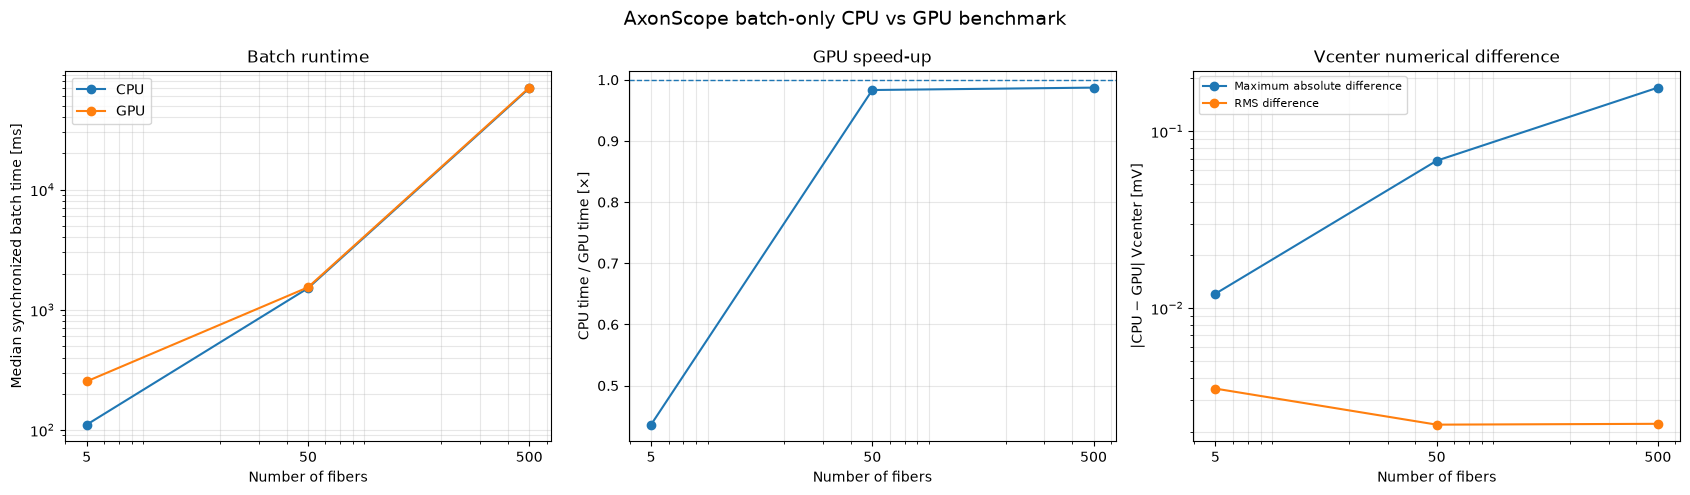

Figure: /content/axonscope_batch_cpu_gpu_results/batch_cpu_vs_gpu_vcenter.png
CSV: /content/axonscope_batch_cpu_gpu_results/batch_cpu_gpu_summary.csv
JSON: /content/axonscope_batch_cpu_gpu_results/batch_cpu_gpu_summary.json


In [6]:
fiber_counts = summary_df["fibers"].to_numpy()

figure, axes = plt.subplots(
    1,
    3,
    figsize=(17, 5),
)

# CPU and GPU runtime.
axes[0].plot(
    fiber_counts,
    summary_df["cpu_median_ms"],
    marker="o",
    label="CPU",
)
axes[0].plot(
    fiber_counts,
    summary_df["gpu_median_ms"],
    marker="o",
    label="GPU",
)
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xticks(
    fiber_counts,
    [str(value) for value in fiber_counts],
)
axes[0].set_xlabel("Number of fibers")
axes[0].set_ylabel(
    "Median synchronized batch time [ms]"
)
axes[0].set_title("Batch runtime")
axes[0].grid(
    True,
    which="both",
    alpha=0.3,
)
axes[0].legend()

# GPU speed-up.
axes[1].plot(
    fiber_counts,
    summary_df["cpu_over_gpu_speedup_x"],
    marker="o",
)
axes[1].axhline(
    1.0,
    linestyle="--",
    linewidth=1,
)
axes[1].set_xscale("log")
axes[1].set_xticks(
    fiber_counts,
    [str(value) for value in fiber_counts],
)
axes[1].set_xlabel("Number of fibers")
axes[1].set_ylabel("CPU time / GPU time [×]")
axes[1].set_title("GPU speed-up")
axes[1].grid(
    True,
    which="both",
    alpha=0.3,
)

# CPU–GPU numerical difference.
axes[2].plot(
    fiber_counts,
    summary_df["max_abs_vcenter_diff_mV"],
    marker="o",
    label="Maximum absolute difference",
)
axes[2].plot(
    fiber_counts,
    summary_df["rms_vcenter_diff_mV"],
    marker="o",
    label="RMS difference",
)
axes[2].set_xscale("log")

difference_values = summary_df[
    [
        "max_abs_vcenter_diff_mV",
        "rms_vcenter_diff_mV",
    ]
].to_numpy()

if np.any(difference_values > 0):
    axes[2].set_yscale("log")

axes[2].set_xticks(
    fiber_counts,
    [str(value) for value in fiber_counts],
)
axes[2].set_xlabel("Number of fibers")
axes[2].set_ylabel("|CPU − GPU| Vcenter [mV]")
axes[2].set_title("Vcenter numerical difference")
axes[2].grid(
    True,
    which="both",
    alpha=0.3,
)
axes[2].legend(fontsize=8)

figure.suptitle(
    "AxonScope batch-only CPU vs GPU benchmark",
    fontsize=14,
)
figure.tight_layout()

figure_path = (
    results_dir
    / "batch_cpu_vs_gpu_vcenter.png"
)

figure.savefig(
    figure_path,
    dpi=160,
    bbox_inches="tight",
)
plt.show()

print("Figure:", figure_path)
print("CSV:", summary_csv)
print("JSON:", summary_json)

## 7. Download all benchmark outputs

In [7]:
import shutil

archive_path = shutil.make_archive(
    "/content/axonscope_batch_cpu_gpu_results",
    "zip",
    root_dir=RESULTS_DIR,
)

print("Archive created:", archive_path)

try:
    from google.colab import files
    files.download(archive_path)
except ImportError:
    print(
        "Outside Colab, retrieve the archive directly:",
        archive_path,
    )

Archive created: /content/axonscope_batch_cpu_gpu_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Notes

- The benchmark times only `axs.simulate_pool(...)` plus the required JAX synchronization.
- Simulation object construction and NumPy export are outside the timed section.
- A full-size warm-up is run separately for every `N`, because JAX compilation depends on array shapes.
- Only one `Vm` column is retained per fiber through `axs.Recording.center("Vm")`.
- The notebook checks that the recorded result shape is `(time, 1)` for every fiber.
- `N = 1000` may require substantial CPU time and GPU memory depending on the selected Colab runtime.